# Project 5 — CNN Image Classification (CIFAR-10)

Exploration notebook: sample data preview, final test-set evaluation of the best checkpoint, confusion matrix, per-class accuracy, and misclassified examples.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

from dataset import get_dataloaders, CLASSES, CIFAR10_MEAN, CIFAR10_STD
from model import CIFAR10CNN

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 1. Load data

In [2]:
train_loader, val_loader, test_loader = get_dataloaders(data_dir='../data', batch_size=128)
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

Train batches: 352 | Val batches: 40 | Test batches: 79


## 2. Preview sample images (denormalized)

/home/seno/.pyenv/versions/dl-portfolio/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


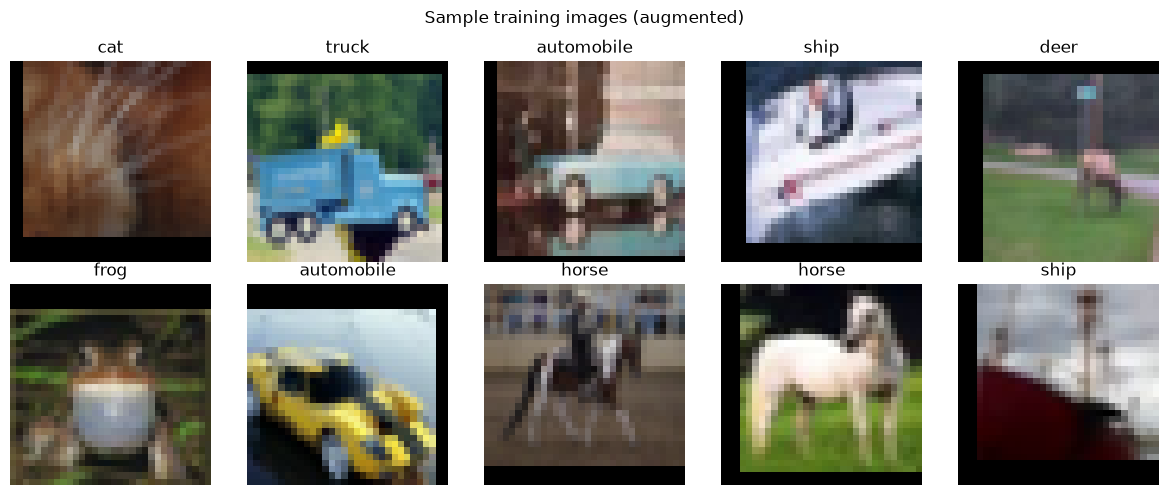

In [3]:
def denormalize(img_tensor):
    mean = torch.tensor(CIFAR10_MEAN).view(3, 1, 1)
    std = torch.tensor(CIFAR10_STD).view(3, 1, 1)
    img = img_tensor * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).numpy()

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(denormalize(images[i]))
    ax.set_title(CLASSES[labels[i]])
    ax.axis('off')
plt.suptitle('Sample training images (augmented)')
plt.tight_layout()
plt.show()

## 3. Load best checkpoint

In [4]:
checkpoint = torch.load('../outputs/best_model.pt', map_location=device)

model = CIFAR10CNN(num_classes=10).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Checkpoint from epoch {checkpoint['epoch']}")
print(f"Val accuracy at checkpoint: {checkpoint['val_acc']:.4f}")

Checkpoint from epoch 48
Val accuracy at checkpoint: 0.8974


## 4. Evaluate on held-out test set

In [5]:
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

test_acc = (all_preds == all_labels).mean()
print(f'Test accuracy: {test_acc:.4f}')
print()
print(classification_report(all_labels, all_preds, target_names=CLASSES))

Test accuracy: 0.8888

              precision    recall  f1-score   support

    airplane       0.89      0.91      0.90      1000
  automobile       0.94      0.94      0.94      1000
        bird       0.87      0.82      0.85      1000
         cat       0.76      0.78      0.77      1000
        deer       0.88      0.90      0.89      1000
         dog       0.84      0.82      0.83      1000
        frog       0.92      0.94      0.93      1000
       horse       0.95      0.90      0.93      1000
        ship       0.92      0.94      0.93      1000
       truck       0.92      0.93      0.93      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



## 5. Confusion matrix

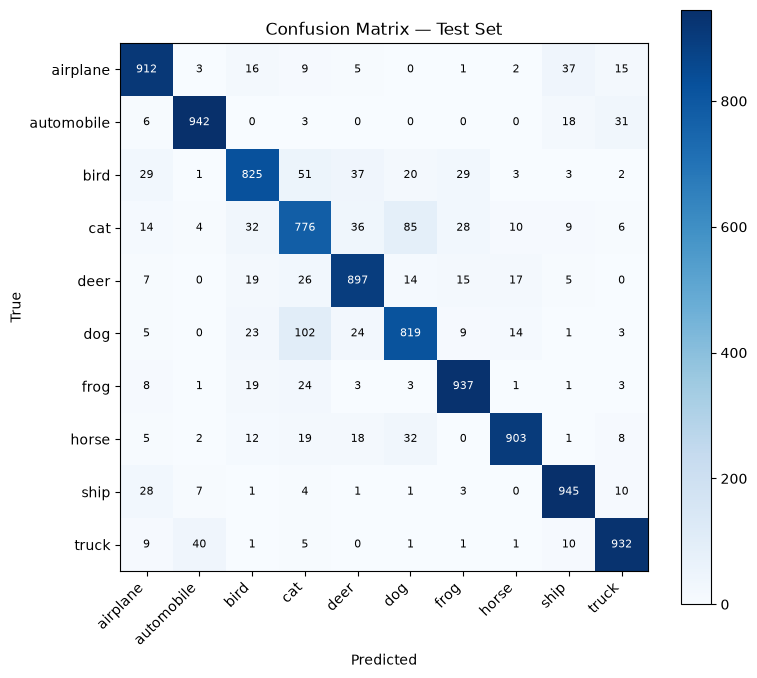

In [6]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(CLASSES, rotation=45, ha='right')
ax.set_yticklabels(CLASSES)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Test Set')

for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=8)

plt.colorbar(im)
plt.tight_layout()
plt.show()

## 6. Per-class accuracy

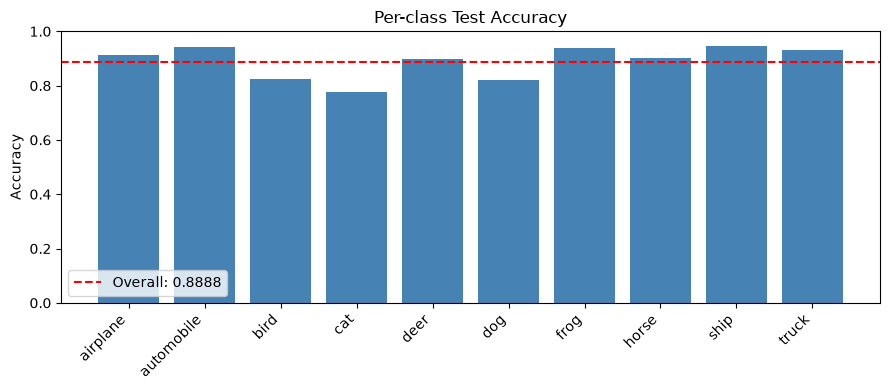

In [7]:
class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(CLASSES, class_acc, color='steelblue')
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('Per-class Test Accuracy')
ax.axhline(test_acc, color='red', linestyle='--', label=f'Overall: {test_acc:.4f}')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Misclassified examples

/home/seno/.pyenv/versions/dl-portfolio/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


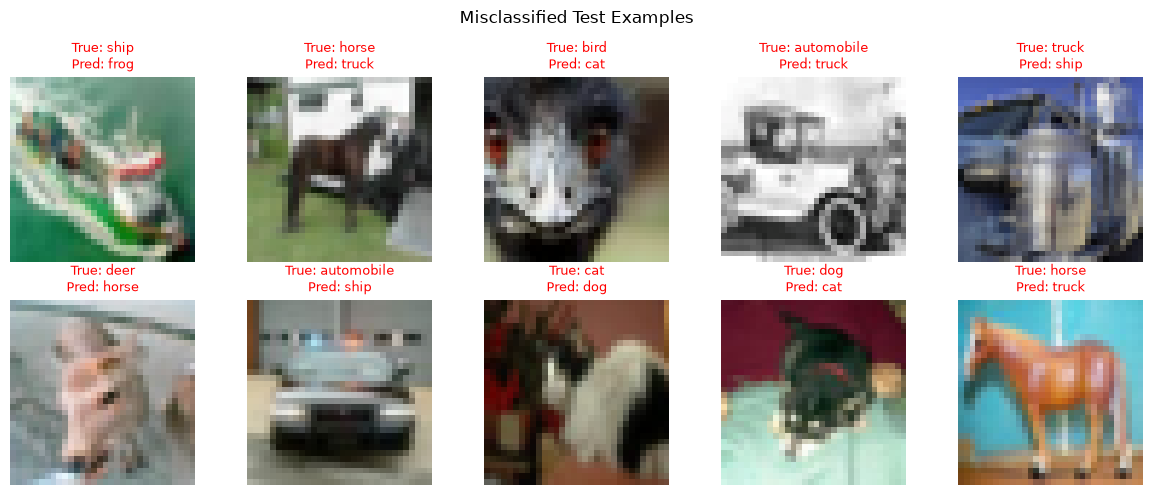

In [8]:
misclassified_images, misclassified_true, misclassified_pred = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images_dev = images.to(device)
        outputs = model(images_dev)
        preds = outputs.argmax(dim=1).cpu()

        wrong_mask = preds != labels
        if wrong_mask.any():
            misclassified_images.extend(images[wrong_mask])
            misclassified_true.extend(labels[wrong_mask].tolist())
            misclassified_pred.extend(preds[wrong_mask].tolist())
        if len(misclassified_images) >= 10:
            break

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    if i >= len(misclassified_images):
        ax.axis('off')
        continue
    ax.imshow(denormalize(misclassified_images[i]))
    true_label = CLASSES[misclassified_true[i]]
    pred_label = CLASSES[misclassified_pred[i]]
    ax.set_title(f'True: {true_label}\nPred: {pred_label}', fontsize=9, color='red')
    ax.axis('off')
plt.suptitle('Misclassified Test Examples')
plt.tight_layout()
plt.show()